## Summary

L'objectif est de construire un modèle de classification capable de **prédire si une personne gagne plus ou moins de 50 000 dollars par an**, en utilisant ses caractéristiques socio-démographiques.

Le jeu de données est **"Adult Income"** du [UCI Machine Learning Repository](https://archive.ics.uci.edu/).

- **[UCIMLREPO](https://github.com/uci-ml-repo/ucimlrepo) package**

Le package UCIMLRepo (pour **UCI Machine Learning Repository**) est une **bibliothèque Python** qui facilite l’accès aux jeux de données disponibles sur le célèbre dépôt [UCI Machine Learning Repository](https://archive.ics.uci.edu/). Il permet de **chercher, télécharger et utiliser facilement ces datasets directement dans un notebook Python**, sans avoir à passer par un téléchargement manuel.

## Packages

In [1]:
from pathlib import Path

import dill
import matplotlib.pyplot as plt
import missingno as msno
import numpy as np
import pandas as pd
import pendulum
import plotly.graph_objects as go
import plotly.express as px
import seaborn as sns
from imblearn.pipeline import Pipeline as imb_Pipeline
from loguru import logger
from sklearn import set_config
from sklearn.compose import make_column_transformer, ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix,
                             classification_report,
                             ConfusionMatrixDisplay,
                             roc_auc_score,
                             accuracy_score,
                             precision_score,
                             recall_score,
                             f1_score,
                             RocCurveDisplay,
                             PrecisionRecallDisplay,
                            )
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OrdinalEncoder, OneHotEncoder
from ucimlrepo import fetch_ucirepo, list_available_datasets
from yellowbrick.classifier import DiscriminationThreshold

set_config(display='diagram')
pd.set_option("display.max_columns", None)

## Settings

In [2]:
EXECUTION_DATE = pendulum.now(tz="UTC")


ROOT_DIR = Path().cwd()
MODEL_DIR = Path(ROOT_DIR, "models")

MODEL_DIR.mkdir(parents=True, exist_ok=True)
logger.info(f"Model directory: {MODEL_DIR}")

2025-04-29 12:08:06.704 | INFO     | __main__:<module>:8 - Model directory: c:\Users\MBAYE\OneDrive\Bureau\SEMESTRE 2\Machine Learning\TP APPLI\models


## Data collection

In [3]:
# check which datasets can be imported
list_available_datasets()

-------------------------------------
The following datasets are available:
-------------------------------------
Dataset Name                                                                            ID    
------------                                                                            --    
Abalone                                                                                 1     
Adult                                                                                   2     
Annealing                                                                               3     
Audiology (Standardized)                                                                8     
Auto MPG                                                                                9     
Automobile                                                                              10    
Balance Scale                                                                           12    
Balloons                       

In [4]:
# fetch dataset 
adult = fetch_ucirepo(name="Adult", id=None) 

# fetch data
data = adult.data.original

logger.info(f"{data.shape}")

2025-04-29 12:08:52.035 | INFO     | __main__:<module>:7 - (48842, 15)


In [5]:
data.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [6]:
# metadata 
logger.info(f"Metadata \n {adult.metadata}") 
  
# variable information 
logger.info(f"Features: \n{adult.variables}") 

2025-04-29 12:08:52.253 | INFO     | __main__:<module>:2 - Metadata 
 {'uci_id': 2, 'name': 'Adult', 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult', 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv', 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ', 'area': 'Social Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 48842, 'num_features': 14, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'], 'target_col': ['income'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1996, 'last_updated': 'Tue Sep 24 2024', 'dataset_doi': '10.24432/C5XW20', 'creators': ['Barry Becker', 'Ronny Kohavi'], 'intro_paper': None, 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census da

In [7]:
data.describe(include="all")

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
count,48842.000000,47879,4.884200e+04,48842,48842.000000,48842,47876,48842,48842,48842,48842.000000,48842.000000,48842.000000,48568,48842
unique,NaN,9,NaN,16,NaN,7,15,6,5,2,NaN,NaN,NaN,42,4
top,NaN,Private,NaN,HS-grad,NaN,Married-civ-spouse,Prof-specialty,Husband,White,Male,NaN,NaN,NaN,United-States,<=50K
freq,NaN,33906,NaN,15784,NaN,22379,6172,19716,41762,32650,NaN,NaN,NaN,43832,24720
mean,38.643585,NaN,1.896641e+05,NaN,10.078089,NaN,NaN,NaN,NaN,NaN,1079.067626,87.502314,40.422382,NaN,NaN
std,13.710510,NaN,1.056040e+05,NaN,2.570973,NaN,NaN,NaN,NaN,NaN,7452.019058,403.004552,12.391444,NaN,NaN
min,17.000000,NaN,1.228500e+04,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,1.000000,NaN,NaN
25%,28.000000,NaN,1.175505e+05,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
50%,37.000000,NaN,1.781445e+05,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
75%,48.000000,NaN,2.376420e+05,NaN,12.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,45.000000,NaN,NaN


In [8]:
data.columns = data.columns.str.replace("-", "_")
data.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education_num',
       'marital_status', 'occupation', 'relationship', 'race', 'sex',
       'capital_gain', 'capital_loss', 'hours_per_week', 'native_country',
       'income'],
      dtype='object')

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education_num   48842 non-null  int64 
 5   marital_status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital_gain    48842 non-null  int64 
 11  capital_loss    48842 non-null  int64 
 12  hours_per_week  48842 non-null  int64 
 13  native_country  48568 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


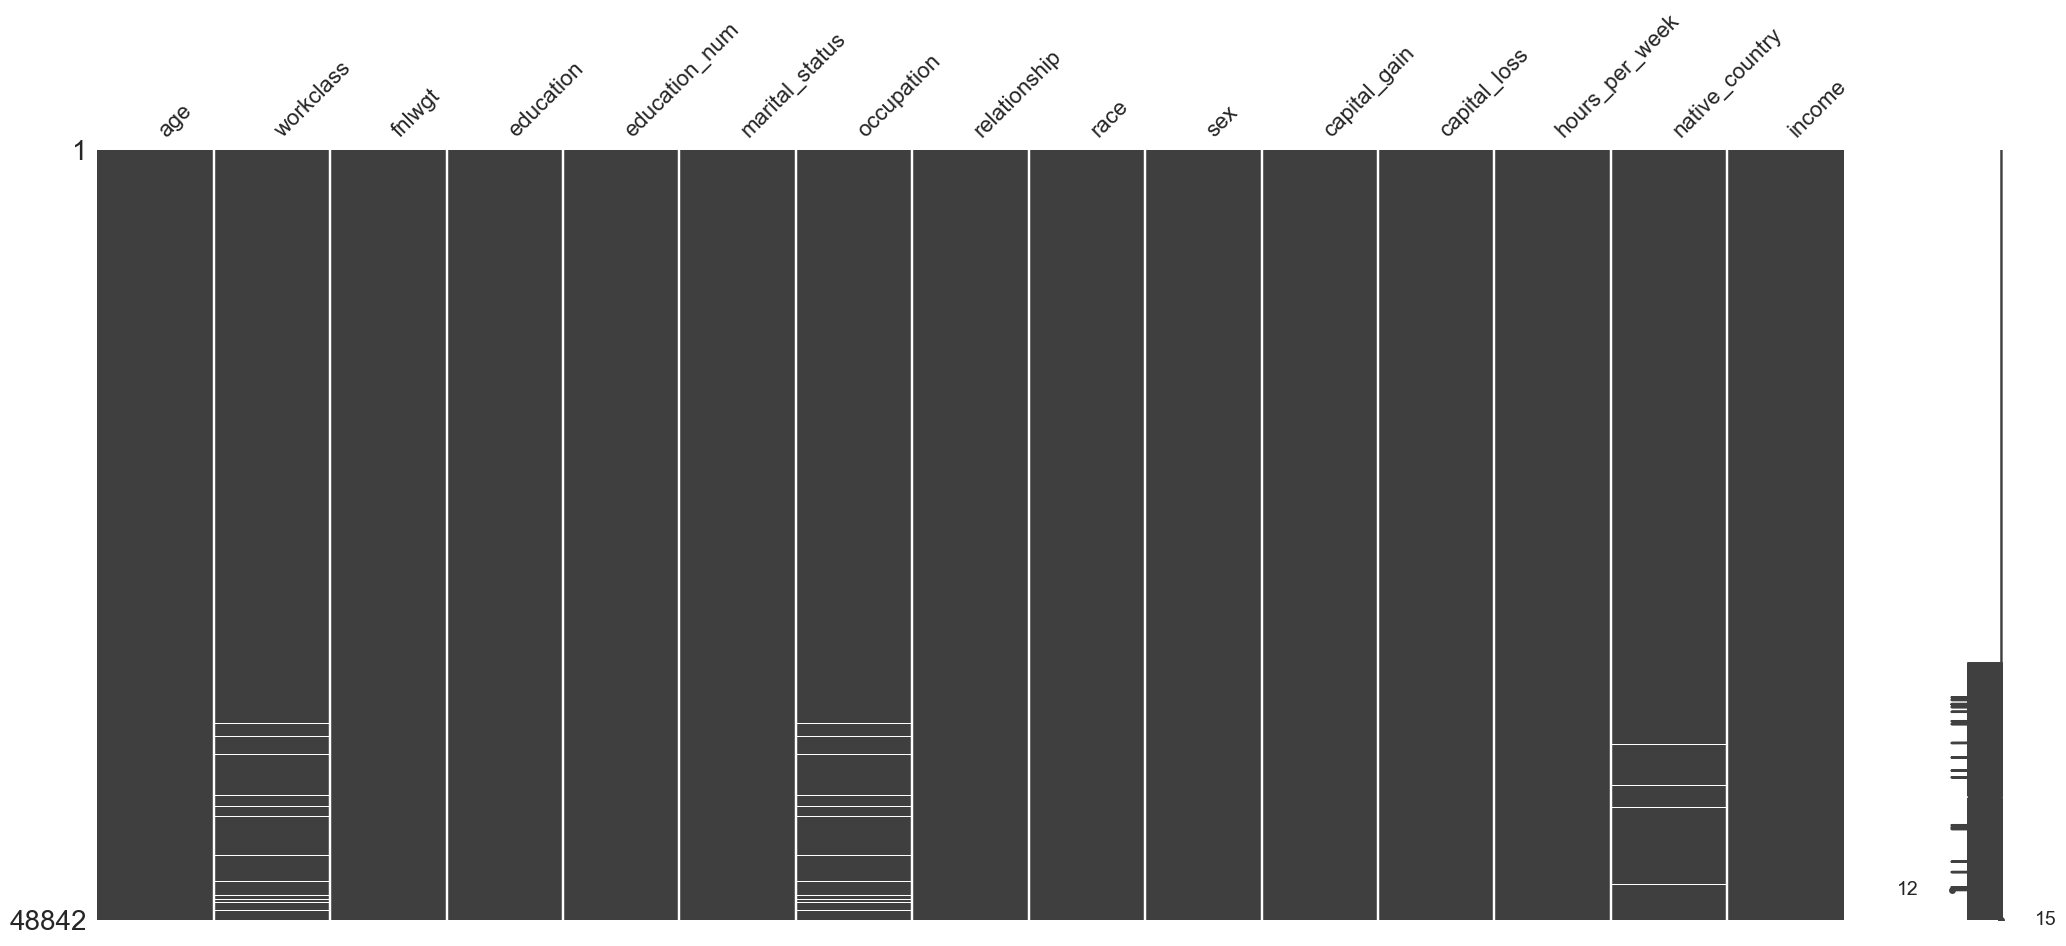

In [10]:
msno.matrix(data);

## EDA: Exploratory Data Analysis

In [11]:
data["income"].value_counts(normalize=False)

income
<=50K     24720
<=50K.    12435
>50K       7841
>50K.      3846
Name: count, dtype: int64

### Target

In [12]:
data = data.assign(income= lambda dfr: dfr.income.str.replace(".", ""))

In [13]:
label_distribution = data.groupby(['income']).size().reset_index(name='count')
label_distribution

,income,count
0,<=50K,37155
1,>50K,11687


In [14]:
# Plot a pie chart with custom colors for income
fig = px.pie(
    label_distribution, 
    names='income',  # Use 'income' for pie segments
    values='count',  # Use 'count' for the size of each pie slice
    # color='income',  # Color the segments based on income
    title='Income distribution',
    labels={'income': 'Income', 'count': 'Count'},
)

fig.update_traces(textinfo='percent+label')  # Display percentage and labels on the pie chart

fig.show()

In [15]:


# Exemple : tracer un graphique camembert
fig = px.pie(
    label_distribution, 
    names='income',      # Les segments
    values='count',      # Taille de chaque segment
    title='Income distribution',
    labels={'income': 'Income', 'count': 'Count'},
)

fig.update_traces(textinfo='percent+label')  # Afficher pourcentage + libellé

fig.show()  # Affiche dans le navigateur


### Categorical features

In [16]:
categorical_columns = data.select_dtypes(include="object").columns

categorical_columns

Index(['workclass', 'education', 'marital_status', 'occupation',
       'relationship', 'race', 'sex', 'native_country', 'income'],
      dtype='object')

In [17]:
for col_name in categorical_columns:
    logger.info(f"{col_name} ==============\n {data[col_name].value_counts(dropna=False)}\n")

2025-04-29 12:09:13.301 | INFO     | __main__:<module>:2 - workclass ==============
 workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
State-gov            1981
?                    1836
Self-emp-inc         1695
Federal-gov          1432
NaN                   963
Without-pay            21
Never-worked           10
Name: count, dtype: int64

2025-04-29 12:09:13.311 | INFO     | __main__:<module>:2 - education ==============
 education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              657
Doctorate         594
5th-6th           509
1st-4th           247
Preschool          83
Name: count, dtype: int64

2025-04-29 12:09:13.324 | INFO     | __main__:<module>:2 - marital_status ==============
 marital_status
Married-civ-spouse       22379
Never-ma

#### Preprocessing

In [18]:
# Replace “?” with None for all columns containing it
data.replace("?", None, inplace=True)

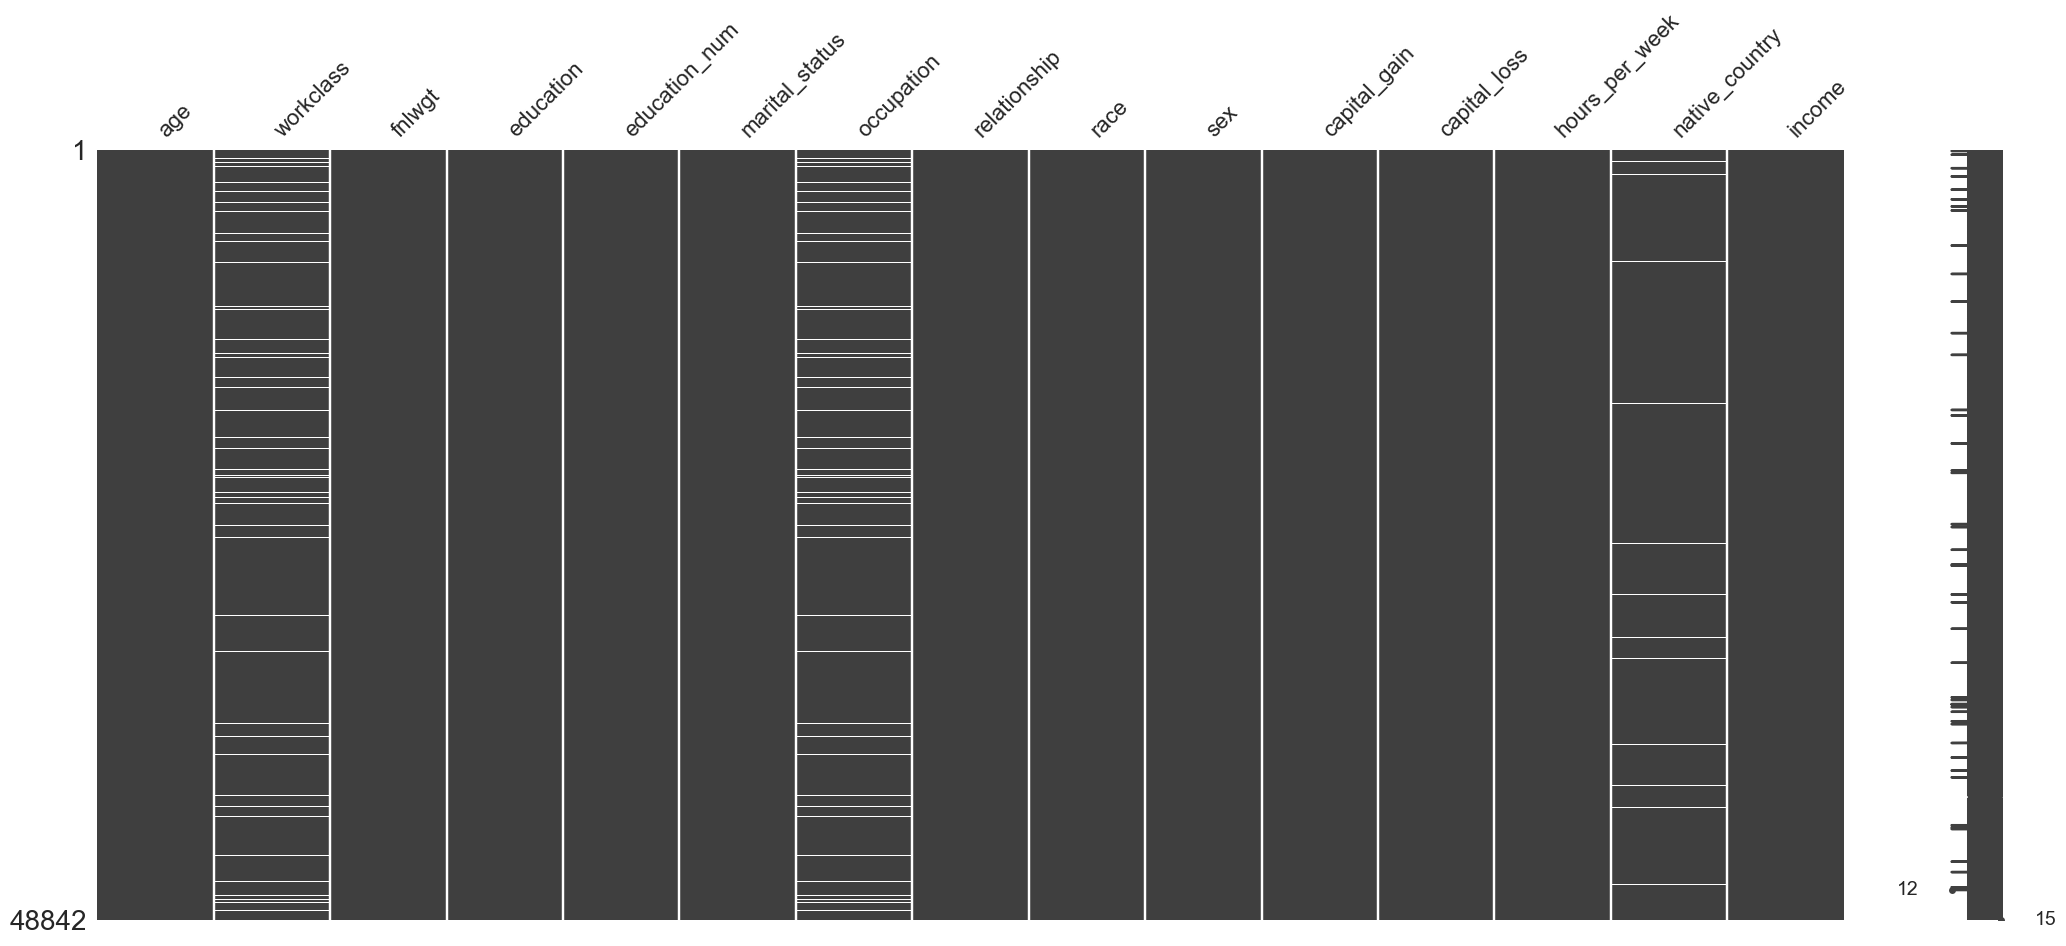

In [19]:
msno.matrix(data);

### Remove Duplicated

In [20]:
# Shape after deduplication
data.shape

(48842, 15)

In [21]:
# Check for the duplicates: if True then there are duplicated
data.duplicated().any()

np.True_

In [22]:
data[data.duplicated(keep=False)].sort_values(["workclass", "education", "relationship"])

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
24667,17,Private,153021,12th,8,Never-married,Sales,Own-child,White,Female,0,0,20,United-States,<=50K
36713,17,Private,153021,12th,8,Never-married,Sales,Own-child,White,Female,0,0,20,United-States,<=50K
5842,25,Private,195994,1st-4th,2,Never-married,Priv-house-serv,Not-in-family,White,Female,0,0,40,Guatemala,<=50K
13084,25,Private,195994,1st-4th,2,Never-married,Priv-house-serv,Not-in-family,White,Female,0,0,40,Guatemala,<=50K
22300,25,Private,195994,1st-4th,2,Never-married,Priv-house-serv,Not-in-family,White,Female,0,0,40,Guatemala,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38993,22,NaN,334593,Some-college,10,Never-married,NaN,Not-in-family,White,Male,0,0,40,United-States,<=50K
10094,19,None,167428,Some-college,10,Never-married,None,Own-child,White,Male,0,0,40,United-States,<=50K
30384,20,None,203353,Some-college,10,Never-married,None,Own-child,White,Female,0,0,40,United-States,<=50K
34424,20,NaN,203353,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,40,United-States,<=50K


In [23]:
# Drop duplicates
data = data.drop_duplicates(keep='first', inplace=False)
data.shape

(48790, 15)

In [24]:
# Shape after deduplication
data.shape

(48790, 15)

### Numerical features

In [25]:
data["capital_diff"] = data['capital_gain'] - data['capital_loss']

In [26]:
numeric_columns = data.select_dtypes(include=['float64', 'int64']).columns

In [27]:
# Initialize a figure
fig = go.Figure()

# Iterate over numeric columns in the DataFrame
for column in numeric_columns:
    fig.add_trace(go.Box(
        y=data[column],
        name=column,
        marker=dict(color='skyblue')
    ))

# Update layout with a title and axis labels
fig.update_layout(
    title='Distribution of Numeric Columns without Outliers',
    yaxis_title='Values',
    xaxis_title='Numeric Columns'
)

# Show the figure
fig.show()


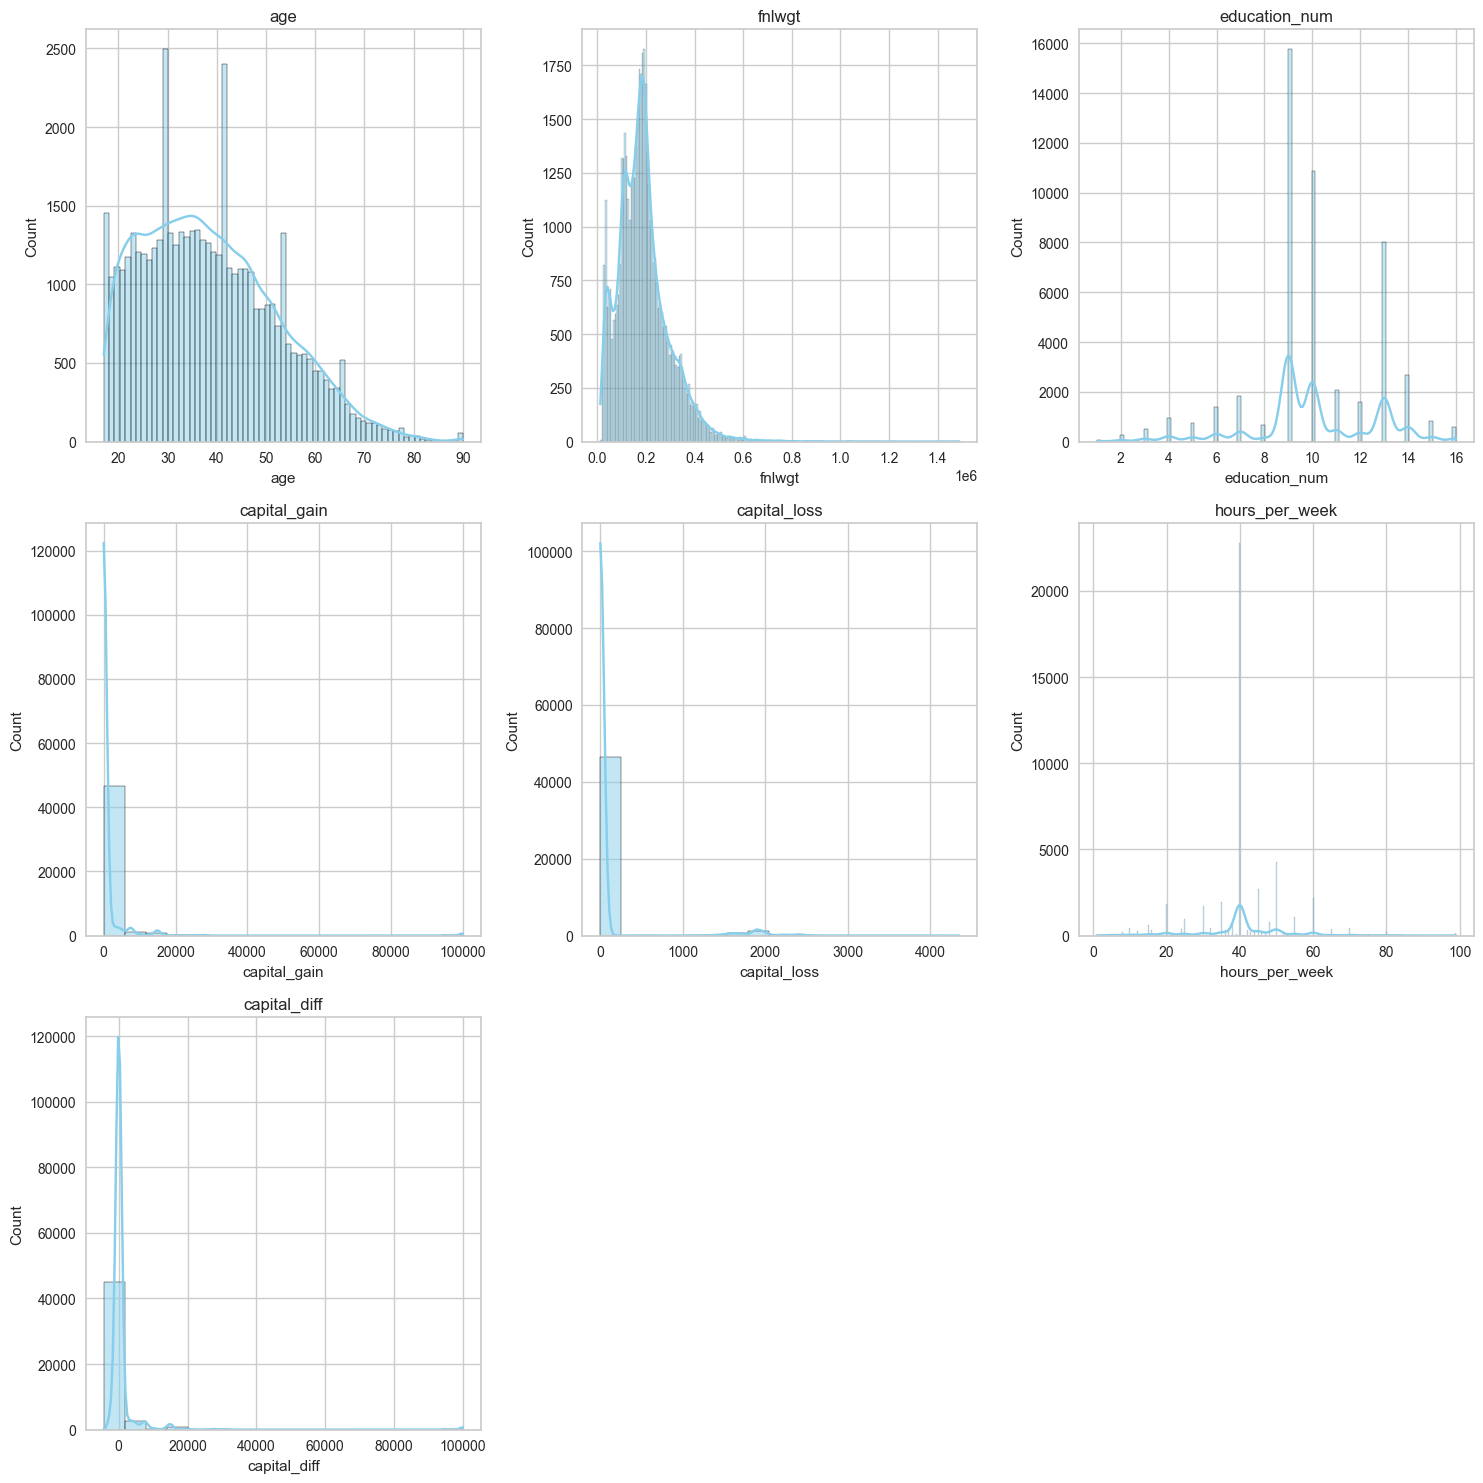

In [28]:
n_cols = 3
n_rows = (len(numeric_columns) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col_name in enumerate(numeric_columns):
    sns.histplot(data[col_name], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(col_name)
    
for i in range(len(numeric_columns), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

### Bivariate analysis

In [29]:
px.box(
    data,
    x='income',  # Income category on the x-axis
    y='age',  # Age distribution on the y-axis
    title='Age Distribution by Income',
    labels={'income': 'Income Category', 'age': 'Age'}
)

In [30]:
data

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,capital_diff
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,2174
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States,<=50K,0
48838,64,NaN,321403,HS-grad,9,Widowed,NaN,Other-relative,Black,Male,0,0,40,United-States,<=50K,0
48839,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,<=50K,0
48840,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,<=50K,5455


In [31]:
for col_name in ["workclass",
                 "education",
                 "marital_status",
                 "sex"
                ]:

    feature_income_counts = data.groupby([col_name, 'income']).size().unstack()
    
    fig = px.bar(feature_income_counts,
                 barmode='stack',  # Stack bars for income categories
                 title=f'Relationship between Income and {col_name}',
                 labels={'value': 'Count'}
                )
    fig.show()

In [32]:
for col_name in numeric_columns:

    #counts
    num_feat_income_counts = data.groupby([col_name, "income"]).size().unstack()
    
    # Plot using iplot
    fig = px.area(num_feat_income_counts,
                  title=f"Relationship between {col_name} and income",
                  labels={"value": "Count"}
                 )
    fig.show()

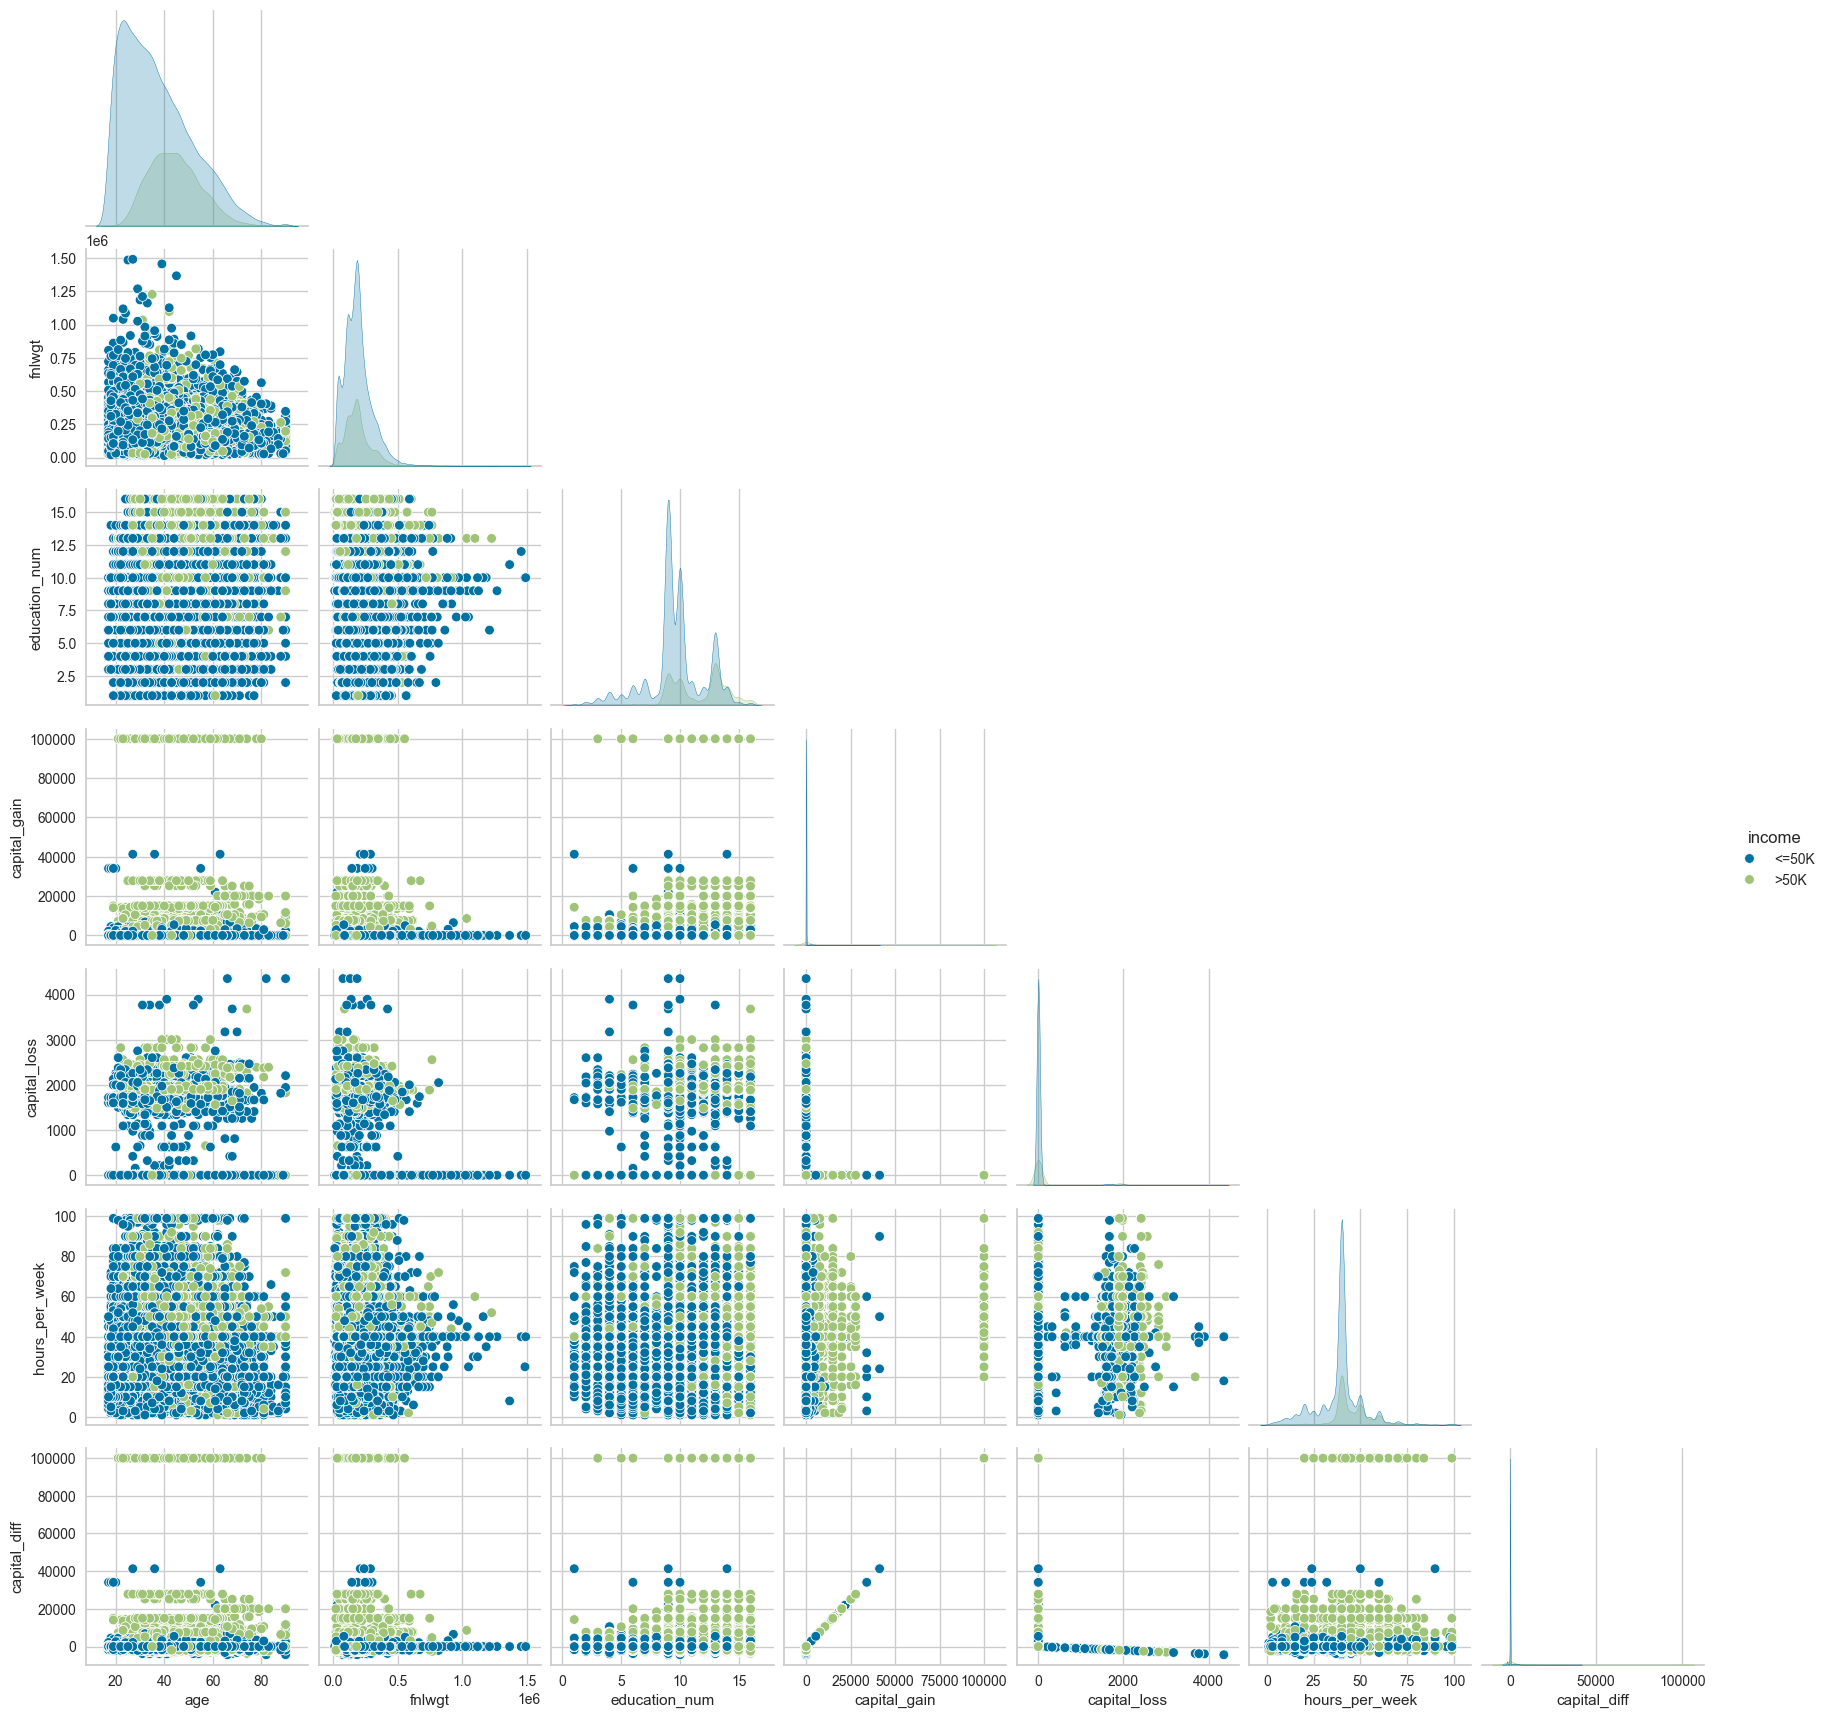

In [33]:
sns.pairplot(data, hue="income", corner=True);

### Correlation

In [34]:
corr_matrix = data.loc[:, numeric_columns].corr()


In [35]:
data.loc[:, numeric_columns].corr()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week,capital_diff
age,1.000000,-0.076451,0.030635,0.077185,0.056838,0.071223,0.073878
fnlwgt,-0.076451,1.000000,-0.038727,-0.003715,-0.004378,-0.013521,-0.003467
education_num,0.030635,-0.038727,1.000000,0.125219,0.080986,0.143915,0.120459
capital_gain,0.077185,-0.003715,0.125219,1.000000,-0.031475,0.082152,0.998547
capital_loss,0.056838,-0.004378,0.080986,-0.031475,1.000000,0.054431,-0.085285
hours_per_week,0.071223,-0.013521,0.143915,0.082152,0.054431,1.000000,0.078959
capital_diff,0.073878,-0.003467,0.120459,0.998547,-0.085285,0.078959,1.000000


<Axes: >

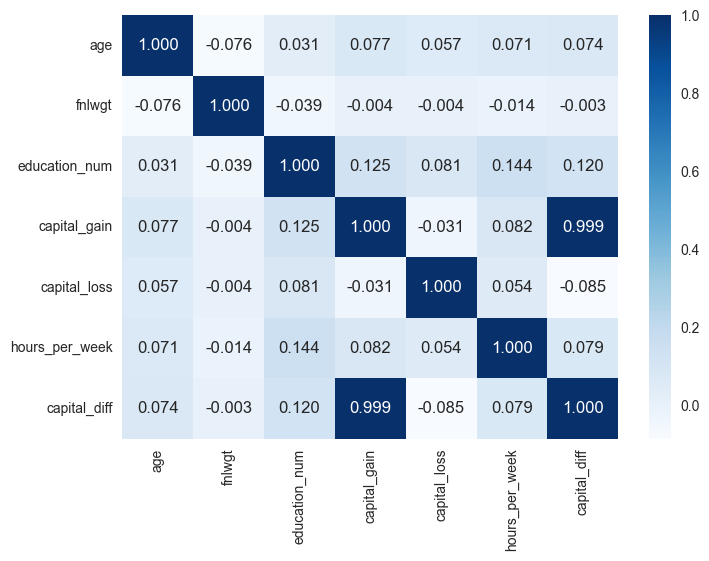

In [36]:
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap="Blues")

## Data preparation

In [37]:
data.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,capital_diff
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,2174
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,0


In [38]:
# Removing rows where 'Workclass' is 'Without-pay' and 'Never-worked'
data = data[~data["workclass"].str.lower().isin(["without-pay", "never-worked"])
            # & data["hours_per_week"].between(20, 60)
           ]
data.shape

(48759, 16)

In [39]:
data["hours_per_week"].value_counts(sort=False).sort_index()

hours_per_week
1      27
2      53
3      59
4      83
5      95
     ... 
95      2
96      9
97      2
98     14
99    137
Name: count, Length: 96, dtype: int64

In [40]:
#Feature mapping
workclass_mapping = {
    'Private': 'Private',
    'Self-emp-not-inc': 'Self-Employed',
    'Local-gov': 'Government',
    'State-gov': 'Government',
    'Self-emp-inc': 'Self-Employed',
    'Federal-gov': 'Government',
    'Without-pay': 'Other',
    'Never-worked': 'Other'
}

marital_status_mapping = {
    "Married-civ-spouse": "Married",
    "Married-spouse-absent": "Married",
    "Married-AF-spouse": "Married",
    "Separated": "Married",
    "Never-married": "Single",
    "Divorced": "Single",
    "Widowed": "Single"
}

relationship_mapping = {
    'Husband': 'spouse',
    'Not-in-family': 'Others:',
    'Own-child': 'Immediate Family',
    'Unmarried': 'Others:',
    'Wife': 'spouse',
    'Other-relative': 'Immediate Family',
}

# occupation
# occupation_mapping = to be defined if necessary

In [41]:
data = data.assign(income=lambda dfr: dfr['income'].map({"<=50K": 0, ">50K": 1}),
                   # capital_diff_bin = lambda dfr: pd.cut(dfr['capital_diff'], bins = [-5000, 5000, 100000], labels = ['Low', 'High'])
                   native_country=lambda dfr: dfr["native_country"].fillna("United-States").map(lambda val: val if val == "United-States" else "Others"),
                   education=lambda dfr: dfr.education.replace(["11th", "9th", "7th-8th", "5th-6th", "10th", "1st-4th", "12th"], "School"),
                   race=lambda dfr: dfr.race.map(lambda val: 'White' if val == 'White' else 'Others'),
                   # workclass=lambda dfr: dfr.workclass.map(workclass_mapping),
                   # marital_status=lambda dfr: dfr.marital_status.map(marital_status_mapping),
                   # relationship=lambda dfr: dfr.relationship.map(relationship_mapping),
                  )

## Train / test split

In [42]:
data.drop(['capital_gain',
           'capital_loss',
           "fnlwgt",  # fnlwgt (Final Weight): Represents the weight assigned to each individual.
           "education_num",
       ], axis=1, inplace=True)
      

In [43]:
x_values = data.drop(columns=['income'])  
y_target = data.income

In [44]:
x_train, x_test, y_train, y_test = train_test_split(x_values, y_target, test_size=0.2, random_state=42, stratify=y_target)

In [45]:
x_train.head()

,age,workclass,education,marital_status,occupation,relationship,race,sex,hours_per_week,native_country,capital_diff
44101,35,Local-gov,Bachelors,Married-civ-spouse,Protective-serv,Husband,White,Male,48,United-States,0
36845,61,Private,HS-grad,Divorced,Machine-op-inspct,Not-in-family,White,Female,40,United-States,0
44706,41,Private,Some-college,Divorced,Sales,Unmarried,White,Male,46,United-States,0
35127,49,Self-emp-not-inc,School,Married-civ-spouse,Farming-fishing,Husband,White,Male,50,United-States,0
41678,37,Self-emp-not-inc,Assoc-voc,Married-civ-spouse,Farming-fishing,Husband,White,Male,60,United-States,0


In [46]:
y_train.value_counts(normalize=True).mul(100).round(2)

income
0    76.05
1    23.95
Name: proportion, dtype: float64

In [47]:
y_train.value_counts(normalize=True).mul(100).round(2)

income
0    76.05
1    23.95
Name: proportion, dtype: float64

### Feature engineering

In [48]:
x_values.head()

,age,workclass,education,marital_status,occupation,relationship,race,sex,hours_per_week,native_country,capital_diff
0,39,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,40,United-States,2174
1,50,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,13,United-States,0
2,38,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,40,United-States,0
3,53,Private,School,Married-civ-spouse,Handlers-cleaners,Husband,Others,Male,40,United-States,0
4,28,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Others,Female,40,Others,0


In [49]:
# numerical
numeric_features = x_values.select_dtypes(include="number").columns

# categorical
onehot_features = ['workclass', 'occupation', 'relationship', 'race', 'sex', 'marital_status']

country_feature = ["native_country"]
ordinal_features = ['education',
                   # 'capital_diff_bin',
                  ]
    
cat_for_edu = ['Preschool', 'School', 'HS-grad','Some-college', 'Assoc-voc', 'Assoc-acdm','Bachelors', 'Masters', 'Prof-school', 'Doctorate']
cat_for_capdiff = ['Low', 'High']

In [50]:
x_train.loc[:, numeric_features]

,age,hours_per_week,capital_diff
44101,35,48,0
36845,61,40,0
44706,41,46,0
35127,49,50,0
41678,37,60,0
...,...,...,...
2324,63,50,0
30520,21,40,0
42196,60,25,0
41858,34,40,0


In [51]:
x_train.loc[:, numeric_features]

,age,hours_per_week,capital_diff
44101,35,48,0
36845,61,40,0
44706,41,46,0
35127,49,50,0
41678,37,60,0
...,...,...,...
2324,63,50,0
30520,21,40,0
42196,60,25,0
41858,34,40,0


In [52]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])


# Education : ordinal + imputation 'undefined' gérée via catégorie manquante
ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='undefined')),
    ('ordinal', OrdinalEncoder(categories=[cat_for_edu + ['undefined']], handle_unknown='use_encoded_value', unknown_value=-1))
])

# OneHot : autres variables catégorielles avec imputation "undefined"
onehot_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='undefined')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Native country : imputation avec "United-States"
country_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='United-States')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Pipeline
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('ord', ordinal_transformer, ordinal_features),
    ('cat', onehot_transformer, onehot_features),
    ('country', country_transformer, country_feature)
])



preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 Index(['age', 'hours_per_week', 'capital_diff'], dtype='object')),
                                ('ord',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(fill_value='undefined',
                                                                strategy='constant')),
                                                 ('ordinal',
                                                  OrdinalEncoder(categories=[['Preschool',
                                                                              'School',
                                                                              'HS-...
                                                  SimpleImputer(fill_value='undefined',
                                                                strategy='constant')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['workclass', 'occupation', 'relationship',
                                  'race', 'sex', 'marital_status']),
                                ('country',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(fill_value='United-States',
                                                                strategy='constant')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['native_country'])])

## Modeling

#### Dummy regressor

In [53]:
# Pipeline
dm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('clf', DummyClassifier())
])

dm_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'hours_per_week', 'capital_diff'], dtype='object')),
                                                 ('ord',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='undefined',
                                                                                 strategy='constant')),
                                                                  ('ordinal',
                                                                   OrdinalEncoder(catego...
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['workclass', 'occupation',
                                                   'relationship', 'race',
                                                   'sex', 'marital_status']),
                                                 ('country',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='United-States',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['native_country'])])),
                ('clf', DummyClassifier())])

In [54]:
# Training
dm_pipeline.fit(x_train, y_train)

# Predictions & evaluation
dm_y_pred_test = dm_pipeline.predict(x_test)
dm_y_proba_test = dm_pipeline.predict_proba(x_test)[:, 1]


logger.info(f"AUC: {roc_auc_score(y_test, dm_y_proba_test):.2f}")

logger.info(f"Classification report: \n{classification_report(y_test, dm_y_pred_test)}")

2025-04-29 12:11:29.722 | INFO     | __main__:<module>:9 - AUC: 0.50
C:\Users\MBAYE\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

C:\Users\MBAYE\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

C:\Users\MBAYE\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 

#### Logistic regression

In [55]:
# Pipeline
rl_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('clf', LogisticRegression(max_iter=1000))
])

rl_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'hours_per_week', 'capital_diff'], dtype='object')),
                                                 ('ord',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='undefined',
                                                                                 strategy='constant')),
                                                                  ('ordinal',
                                                                   OrdinalEncoder(catego...
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['workclass', 'occupation',
                                                   'relationship', 'race',
                                                   'sex', 'marital_status']),
                                                 ('country',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='United-States',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['native_country'])])),
                ('clf', LogisticRegression(max_iter=1000))])

##### Baseline

In [56]:
# 8. Entraînement
rl_pipeline.fit(x_train, y_train)

# 9. Prédictions & évaluation
rl_y_pred_test = rl_pipeline.predict(x_test)
rl_y_proba_test = rl_pipeline.predict_proba(x_test)[:, 1]


logger.info(f"AUC: {roc_auc_score(y_test, rl_y_proba_test):.2f} ")

logger.info(f"Classification report: \n{classification_report(y_test, rl_y_pred_test)}")

2025-04-29 12:11:30.989 | INFO     | __main__:<module>:9 - AUC: 0.90 
2025-04-29 12:11:31.007 | INFO     | __main__:<module>:11 - Classification report: 
              precision    recall  f1-score   support

           0       0.88      0.93      0.90      7416
           1       0.72      0.59      0.65      2336

    accuracy                           0.85      9752
   macro avg       0.80      0.76      0.78      9752
weighted avg       0.84      0.85      0.84      9752



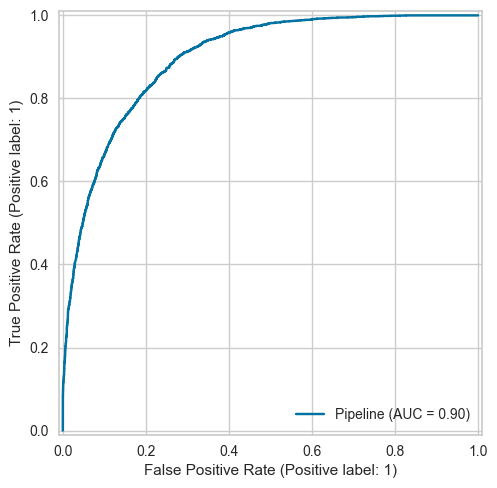

In [57]:
RocCurveDisplay.from_estimator(rl_pipeline, x_test, y_test);

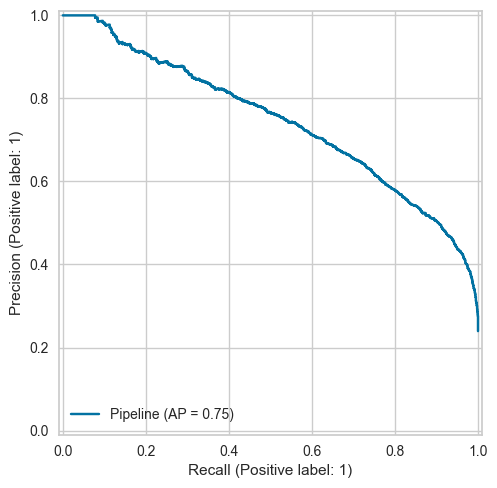

In [58]:
PrecisionRecallDisplay.from_estimator(rl_pipeline, x_test, y_test);


##### Tuning hyperparameters

In [59]:
rl_param_grid = {
    "clf__penalty": ["l2"],  # 'l1' si solver = 'liblinear' ou 'saga'
    "clf__C": [0.01, 0.1, 1, 2, 3, 5, 10],
    "clf__solver": ['liblinear', 'lbfgs', "sag", "saga"],  # lbfgs ne supporte que l2
    "clf__class_weight": ['balanced', None],
}

In [60]:
# Cross-validation
cv = StratifiedKFold(n_splits=5) 

rl_grid_search = GridSearchCV(rl_pipeline, rl_param_grid, cv=cv, scoring='roc_auc', n_jobs=-1)

# Training
rl_grid_search.fit(x_train, y_train)

# Best params
logger.info(f"Best params : {rl_grid_search.best_params_}")

# Evaluation
rl_y_pred_test_opt = rl_grid_search.predict(x_test)
rl_y_proba_test_opt  = rl_grid_search.predict_proba(x_test)[:, 1]

logger.info(f"AUC : {roc_auc_score(y_test, rl_y_proba_test_opt):.2f}")
logger.info(f"F1-score : {f1_score(y_test, rl_y_pred_test_opt):.2f}")
logger.info(f"Accuracy : {accuracy_score(y_test, rl_y_pred_test_opt):.2f}")


2025-04-29 12:20:17.338 | INFO     | __main__:<module>:10 - Best params : {'clf__C': 10, 'clf__class_weight': 'balanced', 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
2025-04-29 12:20:17.463 | INFO     | __main__:<module>:16 - AUC : 0.90
2025-04-29 12:20:17.469 | INFO     | __main__:<module>:17 - F1-score : 0.66
2025-04-29 12:20:17.472 | INFO     | __main__:<module>:18 - Accuracy : 0.79


### Courbe de Lift

In [62]:
data_lift = pd.DataFrame({"y_true": y_test, "y_pred": rl_y_pred_test_opt, "proba": rl_y_proba_test_opt})
data_lift = data_lift.sort_values("proba", ascending=False).reset_index(drop=True)
data_lift.head()
# Decile
data_lift["decile"] = pd.qcut(data_lift.index, 10, labels=False)
data_lift.head()# features importances
# Global positive rate
global_positive_rate =  data_lift["y_true"].sum() / len(data_lift)
global_positive_rate
lift_aggregate_table = data_lift.groupby("decile")["y_true"].agg(["sum", "count"])

In [64]:
lift_aggregate_table["cum_positives"] = lift_aggregate_table["sum"].cumsum()

lift_aggregate_table["positive_rate_cum"] = lift_aggregate_table["cum_positives"] / lift_aggregate_table["count"].cumsum()
lift_aggregate_table["lift_score"] = lift_aggregate_table["positive_rate_cum"] / global_positive_rate

lift_aggregate_table["percent_sample"] = 10 * (lift_aggregate_table.index + 1)

lift_aggregate_table
px.line(
    lift_aggregate_table,
    x="percent_sample",
    y="lift_score",
    labels={
        "percent_sample": "Cumulative % of Sample",
        "lift_score": "Lift Score"
    },
    title="Lift Curve"
)

##### Discrimination threshold

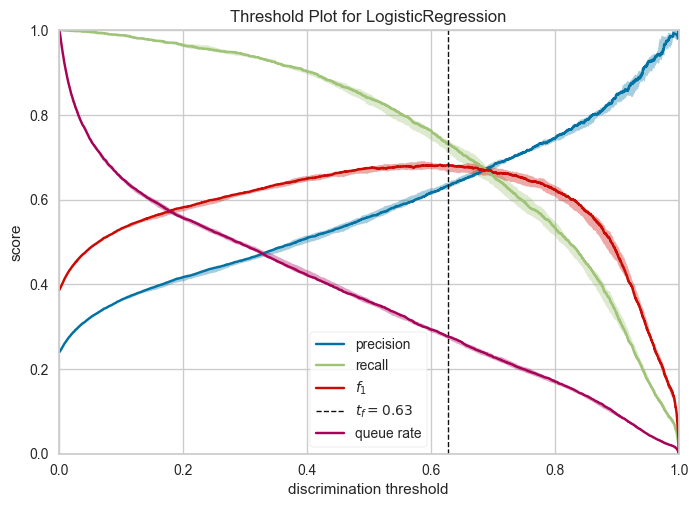

In [65]:
viz = DiscriminationThreshold(rl_grid_search.best_estimator_, random_state=42, fbeta=1.0, cv=cv, argmax="fscore")

# Fit et plot
viz.fit(x_train, y_train)
viz.score(x_test, y_test)
viz.show();

##### Model analysis

##### Save model

In [66]:
# Save model

model_path_name = Path(MODEL_DIR, "best_logistic_model.dill")

logger.info(f"Model path name: {model_path_name}")
with open(model_path_name, "wb") as fp:
    dill.dump(rl_grid_search.best_estimator_, fp)

2025-04-29 12:36:52.274 | INFO     | __main__:<module>:5 - Model path name: c:\Users\MBAYE\OneDrive\Bureau\SEMESTRE 2\Machine Learning\TP APPLI\models\best_logistic_model.dill


### KNN

#### Baseline

In [67]:
# Pipeline
knn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('clf', KNeighborsClassifier(n_neighbors=10))
])

knn_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'hours_per_week', 'capital_diff'], dtype='object')),
                                                 ('ord',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='undefined',
                                                                                 strategy='constant')),
                                                                  ('ordinal',
                                                                   OrdinalEncoder(catego...
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['workclass', 'occupation',
                                                   'relationship', 'race',
                                                   'sex', 'marital_status']),
                                                 ('country',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='United-States',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['native_country'])])),
                ('clf', KNeighborsClassifier(n_neighbors=10))])

In [68]:
# 8. Entraînement
knn_pipeline.fit(x_train, y_train)

# 9. Prédictions & évaluation
knn_y_pred_test = knn_pipeline.predict(x_test)
knn_y_proba_test = knn_pipeline.predict_proba(x_test)[:, 1]


logger.info(f"AUC: {roc_auc_score(y_test, knn_y_proba_test):.2f}")

logger.info(f"Classification report: \n{classification_report(y_test, knn_y_pred_test)}")

2025-04-29 12:38:41.797 | INFO     | __main__:<module>:9 - AUC: 0.88
2025-04-29 12:38:41.845 | INFO     | __main__:<module>:11 - Classification report: 
              precision    recall  f1-score   support

           0       0.87      0.93      0.90      7416
           1       0.73      0.56      0.63      2336

    accuracy                           0.84      9752
   macro avg       0.80      0.75      0.77      9752
weighted avg       0.84      0.84      0.84      9752



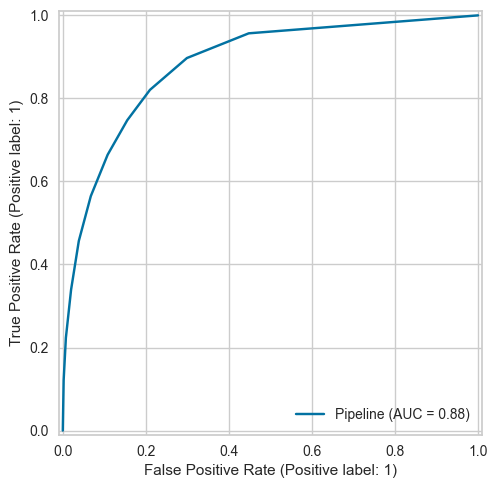

In [71]:
RocCurveDisplay.from_estimator(knn_pipeline, x_test, y_test);

# MODELES EMSEMBLISTES

Nous allons tester deux modèles ensemblistes notamment le RandomForest et le XgBoost.

### Random Forest

In [73]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])
rf_pipeline

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'hours_per_week', 'capital_diff'], dtype='object')),
                                                 ('ord',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='undefined',
                                                                                 strategy='constant')),
                                                                  ('ordinal',
                                                                   OrdinalEncoder(categ...
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['workclass', 'occupation',
                                                   'relationship', 'race',
                                                   'sex', 'marital_status']),
                                                 ('country',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='United-States',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['native_country'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

#### Fitting

In [75]:
rf_pipeline.fit(x_train, y_train)


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'hours_per_week', 'capital_diff'], dtype='object')),
                                                 ('ord',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='undefined',
                                                                                 strategy='constant')),
                                                                  ('ordinal',
                                                                   OrdinalEncoder(categ...
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['workclass', 'occupation',
                                                   'relationship', 'race',
                                                   'sex', 'marital_status']),
                                                 ('country',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='United-States',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['native_country'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

#### Métriques

In [77]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Prédiction
y_pred_rf = rf_pipeline.predict(x_test)

# Métriques
acc_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, average='binary')  # ou 'macro' si multiclasse
recall_rf = recall_score(y_test, y_pred_rf, average='binary')
f1_rf = f1_score(y_test, y_pred_rf, average='binary')
cm_rf = confusion_matrix(y_test, y_pred_rf)
report_rf = classification_report(y_test, y_pred_rf)

# Affichage
print(f"Random Forest Accuracy : {acc_rf:.4f}")
print(f"Precision             : {precision_rf:.4f}")
print(f"Recall                : {recall_rf:.4f}")
print(f"F1 Score              : {f1_rf:.4f}")
print("Confusion Matrix :\n", cm_rf)
print("\nClassification Report :\n", report_rf)


Random Forest Accuracy : 0.8464
Precision             : 0.6980
Recall                : 0.6323
F1 Score              : 0.6635
Confusion Matrix :
 [[6777  639]
 [ 859 1477]]

Classification Report :
               precision    recall  f1-score   support

           0       0.89      0.91      0.90      7416
           1       0.70      0.63      0.66      2336

    accuracy                           0.85      9752
   macro avg       0.79      0.77      0.78      9752
weighted avg       0.84      0.85      0.84      9752



#### Matrice de confusion

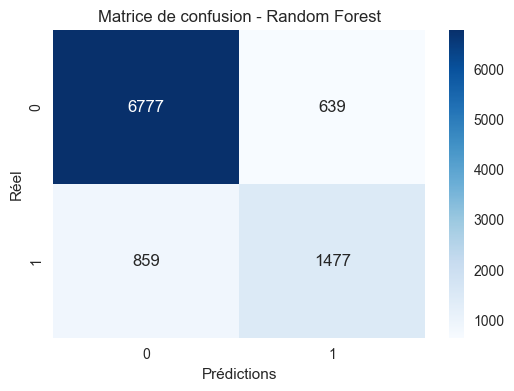

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matrice de confusion - Random Forest')
plt.xlabel('Prédictions')
plt.ylabel('Réel')
plt.show()


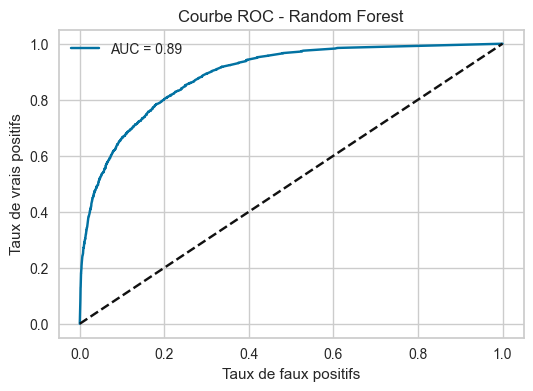

In [80]:
from sklearn.metrics import roc_curve, roc_auc_score

# Probabilité prédite
y_proba_rf = rf_pipeline.predict_proba(x_test)[:, 1]

# ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba_rf)
auc_score = roc_auc_score(y_test, y_proba_rf)

# Tracé
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title('Courbe ROC - Random Forest')
plt.legend()
plt.show()


### XGBoost

In [81]:
from xgboost import XGBClassifier

xgb_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('classifier', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'))
])
xgb_pipeline

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'hours_per_week', 'capital_diff'], dtype='object')),
                                                 ('ord',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='undefined',
                                                                                 strategy='constant')),
                                                                  ('ordinal',
                                                                   OrdinalEncoder(categ...
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, random_state=42, ...))])

In [83]:
xgb_pipeline.fit(x_train, y_train)


C:\Users\MBAYE\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\xgboost\core.py:158: UserWarning:

[13:21:49] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.




Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'hours_per_week', 'capital_diff'], dtype='object')),
                                                 ('ord',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='undefined',
                                                                                 strategy='constant')),
                                                                  ('ordinal',
                                                                   OrdinalEncoder(categ...
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, random_state=42, ...))])

In [85]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Prédiction
y_pred_xgb = xgb_pipeline.predict(x_test)

# Métriques
acc_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb, average='binary')  # ou 'macro' selon le cas
recall_xgb = recall_score(y_test, y_pred_xgb, average='binary')
f1_xgb = f1_score(y_test, y_pred_xgb, average='binary')
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
report_xgb = classification_report(y_test, y_pred_xgb)

# Affichage
print(f"XGBoost Accuracy       : {acc_xgb:.4f}")
print(f"Precision              : {precision_xgb:.4f}")
print(f"Recall                 : {recall_xgb:.4f}")
print(f"F1 Score               : {f1_xgb:.4f}")
print("Confusion Matrix :\n", cm_xgb)
print("\nClassification Report :\n", report_xgb)


XGBoost Accuracy       : 0.8736
Precision              : 0.7666
Recall                 : 0.6789
F1 Score               : 0.7201
Confusion Matrix :
 [[6933  483]
 [ 750 1586]]

Classification Report :
               precision    recall  f1-score   support

           0       0.90      0.93      0.92      7416
           1       0.77      0.68      0.72      2336

    accuracy                           0.87      9752
   macro avg       0.83      0.81      0.82      9752
weighted avg       0.87      0.87      0.87      9752



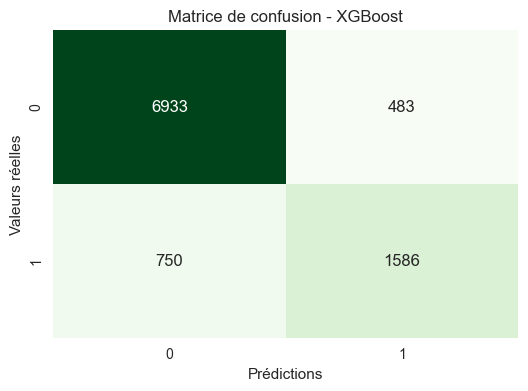

In [86]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title('Matrice de confusion - XGBoost')
plt.xlabel('Prédictions')
plt.ylabel('Valeurs réelles')
plt.show()


## Choix du  meilleur modèle 


In [88]:
metrics = {
    'Modèle': ['Random Forest', 'XGBoost'],
    'Accuracy': [acc_rf, acc_xgb],
    'Precision': [precision_rf, precision_xgb],
    'Recall': [recall_rf, recall_xgb],
    'F1 Score': [f1_rf, f1_xgb],
    
}

import pandas as pd

results_df = pd.DataFrame(metrics)
results_df.set_index('Modèle', inplace=True)
print(results_df)


               Accuracy  Precision    Recall  F1 Score
Modèle                                                
Random Forest  0.846390   0.698015  0.632277  0.663522
XGBoost        0.873564   0.766554  0.678938  0.720091


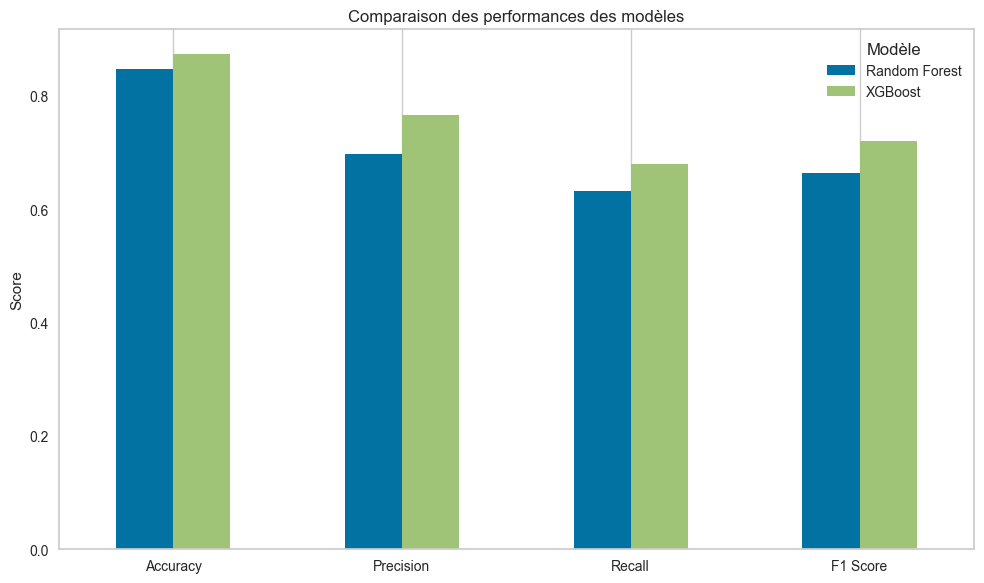

In [89]:
results_df.T.plot(kind='bar', figsize=(10, 6))
plt.title('Comparaison des performances des modèles')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(title='Modèle')
plt.grid(axis='y')
plt.tight_layout()
plt.show()


Après analyse comparative des performances des deux modèles, XGBoost s'est révélé supérieur à Random Forest sur l'ensemble des métriques évaluées (accuracy, précision, rappel, F1-score). Ainsi, XGBoost est retenu comme le modèle final, car il offre les meilleures performances globales sur notre jeu de test.

### Étude la feature importance global et local avec shap


In [ ]:
##pip install shap

     -------------------------------------- 544.8/544.8 KB 1.4 MB/s eta 0:00:00
     ---------------------------------------- 2.7/2.7 MB 3.2 MB/s eta 0:00:00
     ---------------------------------------- 28.1/28.1 MB 1.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'C:\Users\MBAYE\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip' command.


#### Importance globale avec SHAP

C:\Users\MBAYE\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\tqdm\auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html



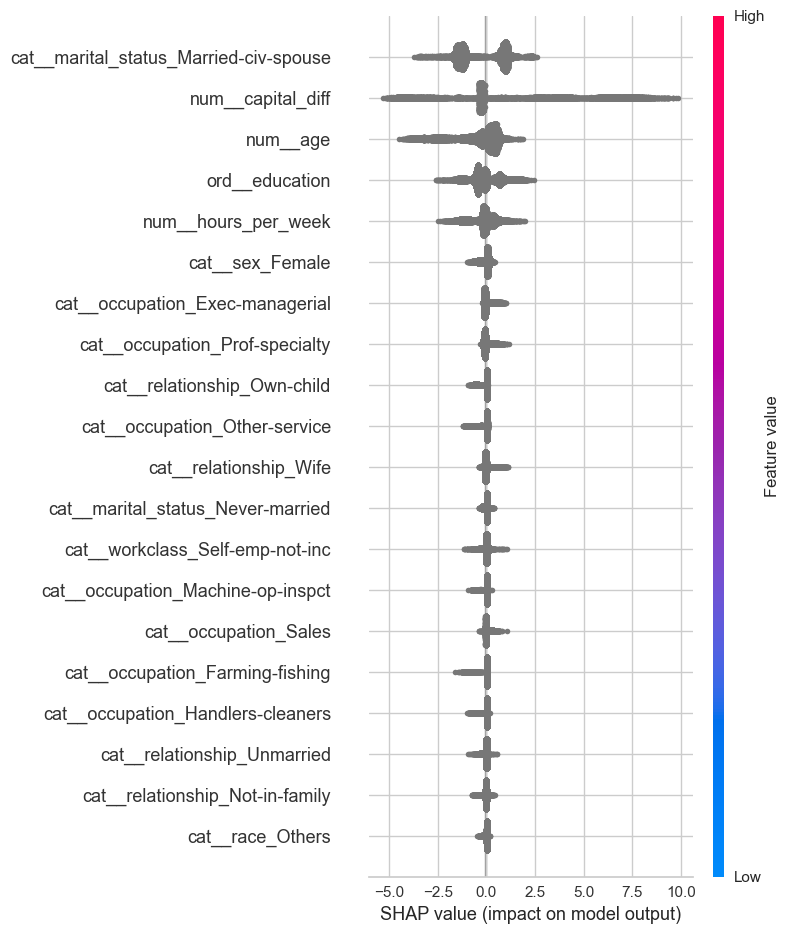

In [91]:
import shap


# Extraire les données transformées
X_train_transformed = xgb_pipeline.named_steps['preprocessing'].transform(x_train)

# Extraire le modèle entraîné
xgb_model = xgb_pipeline.named_steps['classifier']

# Créer l'explainer
explainer = shap.Explainer(xgb_model)

# Calculer les valeurs SHAP
shap_values = explainer(X_train_transformed)

# Visualiser l'importance globale
shap.summary_plot(shap_values, X_train_transformed, feature_names=preprocessor.get_feature_names_out())


#### Importance locale 

In [94]:
# Si X_train_transformed est une matrice sparse, on la convertit
if hasattr(X_train_transformed, "toarray"):
    X_train_transformed_dense = X_train_transformed.toarray()
else:
    X_train_transformed_dense = X_train_transformed

# Idem pour l'instance à expliquer
instance = X_train_transformed_dense[0]


In [96]:
 ## 6. Préparer les éléments pour force_plot
instance_idx = 0  # Modifier si vous voulez expliquer une autre instance
instance = X_train_transformed_dense[instance_idx]

# 7. Initialiser JavaScript pour la visualisation interactive (utile en Jupyter)
shap.initjs()

# 8. Afficher l'explication locale
shap.force_plot(
    base_value=shap_values.base_values[instance_idx],
    shap_values=shap_values.values[instance_idx],
    features=instance,
    feature_names=preprocessor.get_feature_names_out()
)


### Optimisation du modele et l'enregistrer sous format dill

In [ ]:
# Paramètres à tester (petite grille pour la démo)
param_grid = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [3, 5],
    'classifier__learning_rate': [0.05, 0.1]
}

# Recherche par validation croisée
grid_search = GridSearchCV(xgb_pipeline, param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(x_train, y_train)

# Pipeline final entraîné avec les meilleurs paramètres
best_pipeline = grid_search.best_estimator_

Fitting 3 folds for each of 8 candidates, totalling 24 fits


C:\Users\MBAYE\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\xgboost\core.py:158: UserWarning:

[14:25:57] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.




#### Enregistrement du modèle au format .dill

In [100]:
# Save model

model_path_name = Path(MODEL_DIR, "best_XGboost_model.dill")

logger.info(f"Model path name: {model_path_name}")
with open(model_path_name, "wb") as fp:
    dill.dump(grid_search.best_estimator_, fp)

2025-04-29 14:33:45.131 | INFO     | __main__:<module>:5 - Model path name: c:\Users\MBAYE\OneDrive\Bureau\SEMESTRE 2\Machine Learning\TP APPLI\models\best_XGboost_model.dill
